# 공공자전거 군집분석 · 분류분석 · 모형 최적화

- 수요예측 노트북(회귀)은 "몇 대"를 예측합니다. 현장에서는 "어느 구가 부족한가?"라는 **판단(분류)**이 더 직접적으로 쓰이고, 클래스별 재현율로 "부족을 놓치지 않는지" 평가할 수 있습니다.

- 군집 결과(대여소 유형 구성 비율)를 분류 모델의 특성으로 다시 사용해서 2장과 3장을 연결합니다.

# 설정

In [1]:
import os, re, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

In [2]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [3]:
BASE_DIR = r"C:\ai\source\09_project\00_data"            # 연도별 폴더의 상위 폴더
OUT_DIR  = r"C:\ai\source\09_project\03_cluster_class"   # 결과 저장 폴더
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
HORIZON = 7               # 며칠 뒤 상태를 예측할지
MIN_DAILY_RENT = 1.0      # 하루 평균 대여 1건 미만인 대여소는 군집에서 제외 (패턴이 불안정)
RANDOM_STATE = 42

HOLIDAYS = pd.to_datetime([
    '2020-01-01', '2020-01-24', '2020-01-25', '2020-01-26', '2020-01-27', '2020-03-01', '2020-04-15',
    '2020-04-30', '2020-05-05', '2020-06-06', '2020-08-15', '2020-08-17', '2020-09-30', '2020-10-01',
    '2020-10-02', '2020-10-03', '2020-10-09', '2020-12-25',
    '2021-01-01', '2021-02-11', '2021-02-12', '2021-02-13', '2021-03-01', '2021-05-05', '2021-05-19',
    '2021-06-06', '2021-08-15', '2021-08-16', '2021-09-20', '2021-09-21', '2021-09-22', '2021-10-03',
    '2021-10-04', '2021-10-09', '2021-10-11', '2021-12-25',
    '2022-01-01', '2022-01-31', '2022-02-01', '2022-02-02', '2022-03-01', '2022-03-09', '2022-05-05',
    '2022-05-08', '2022-06-01', '2022-06-06', '2022-08-15', '2022-09-09', '2022-09-10', '2022-09-11',
    '2022-09-12', '2022-10-03', '2022-10-09', '2022-10-10', '2022-12-25',
    '2023-01-01', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24', '2023-03-01', '2023-05-05',
    '2023-05-27', '2023-05-29', '2023-06-06', '2023-08-15', '2023-09-28', '2023-09-29', '2023-09-30',
    '2023-10-02', '2023-10-03', '2023-10-09', '2023-12-25',
    '2024-01-01', '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12', '2024-03-01', '2024-04-10',
    '2024-05-05', '2024-05-06', '2024-05-15', '2024-06-06', '2024-08-15', '2024-09-16', '2024-09-17',
    '2024-09-18', '2024-10-01', '2024-10-03', '2024-10-09', '2024-12-25',
    '2025-01-01', '2025-01-27', '2025-01-28', '2025-01-29', '2025-01-30', '2025-03-01', '2025-03-03',
    '2025-05-05', '2025-05-06', '2025-06-03', '2025-06-06', '2025-08-15', '2025-10-03', '2025-10-05',
    '2025-10-06', '2025-10-07', '2025-10-08', '2025-10-09', '2025-12-25'])

def save(name):
    plt.savefig(os.path.join(OUT_DIR, name), dpi=150, bbox_inches='tight')

files = sorted(glob.glob(os.path.join(BASE_DIR, '**', '*_merge.csv'), recursive=True), key=os.path.basename)
files = [f for f in files if re.match(r'^\d{4}_merge\.csv$', os.path.basename(f))]
print('파일 수:', len(files), [os.path.basename(f)[:4] for f in files])

파일 수: 72 ['2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2101', '2102', '2103', '2104', '2105', '2106', '2107', '2108', '2109', '2110', '2111', '2112', '2201', '2202', '2203', '2204', '2205', '2206', '2207', '2208', '2209', '2210', '2211', '2212', '2301', '2302', '2303', '2304', '2305', '2306', '2307', '2308', '2309', '2310', '2311', '2312', '2401', '2402', '2403', '2404', '2405', '2406', '2407', '2408', '2409', '2410', '2411', '2412', '2501', '2502', '2503', '2504', '2505', '2506', '2507', '2508', '2509', '2510', '2511', '2512']


# 집계: 대여소 단위(군집용) + 자치구×날짜 단위(분류용)

- 대여소는 대여 대여소명 기준입니다. 같은 이름이 여러 자치구에 기록된 경우 가장 많이 나온 자치구로 정합니다.

- 휴무일 = 주말 + 공휴일

In [5]:
def parse_dt(s):
    p = s.astype(str).str.extract(r'(\d{4})-(\d{1,2})-(\d{1,2})\s+(\d{1,2}):(\d{2})').astype(float)
    return pd.to_datetime(dict(year=p[0], month=p[1], day=p[2], hour=p[3], minute=p[4]), errors='coerce')

def aggregate_file(path):
    t = time.time()
    df = pd.read_csv(path, encoding='utf-8-sig', low_memory=False)
    df.columns = df.columns.str.replace(' ', '')
    rd, bd = parse_dt(df['대여일시']), parse_dt(df['반납일시'])
    r_off = ((rd.dt.dayofweek >= 5) | rd.dt.normalize().isin(HOLIDAYS)).astype(int)
    b_off = ((bd.dt.dayofweek >= 5) | bd.dt.normalize().isin(HOLIDAYS)).astype(int)

    r = pd.DataFrame({'대여소': df['대여대여소명'], '자치구': df['대여자치구'], 'date': rd.dt.normalize(),
                      'hour': rd.dt.hour, 'off': r_off, 'month': rd.dt.month}).dropna()
    b = pd.DataFrame({'대여소': df['반납대여소명'], '자치구': df['반납자치구'], 'date': bd.dt.normalize(),
                      'hour': bd.dt.hour, 'off': b_off}).dropna()
    out = (r.groupby(['대여소', '자치구', 'hour', 'off']).size().rename('cnt').reset_index(),
           b.groupby(['대여소', 'hour', 'off']).size().rename('cnt').reset_index(),
           r.groupby(['대여소', 'month']).size().rename('cnt').reset_index(),
           r.groupby(['자치구', 'date']).size().rename('rent').reset_index(),
           b.groupby(['자치구', 'date']).size().rename('ret').reset_index())
    print(f'{os.path.basename(path)}: {len(df):>10,}건, {time.time() - t:.1f}초')
    return out

parts = [aggregate_file(f) for f in files]
st_rent, st_ret, st_month, gu_rent, gu_ret = [pd.concat(p, ignore_index=True) for p in zip(*parts)]
del parts
st_rent = st_rent.groupby(['대여소', '자치구', 'hour', 'off'], as_index=False)['cnt'].sum()
st_ret = st_ret.groupby(['대여소', 'hour', 'off'], as_index=False)['cnt'].sum()
st_month = st_month.groupby(['대여소', 'month'], as_index=False)['cnt'].sum()
gu_rent = gu_rent.groupby(['자치구', 'date'], as_index=False)['rent'].sum()
gu_ret = gu_ret.groupby(['자치구', 'date'], as_index=False)['ret'].sum()

for name, t in [('st_rent', st_rent), ('st_ret', st_ret), ('st_month', st_month), ('gu_rent', gu_rent), ('gu_ret', gu_ret)]:
    t.to_csv(os.path.join(OUT_DIR, f'agg_{name}.csv'), index=False, encoding='utf-8-sig')
print('대여소 수:', st_rent['대여소'].nunique(), '| 자치구×날짜:', len(gu_rent))

2001_merge.csv:    360,671건, 3.9초
2002_merge.csv:    355,204건, 3.9초
2003_merge.csv:    634,374건, 7.4초
2004_merge.csv:    829,504건, 9.6초
2005_merge.csv:    885,244건, 10.2초
2006_merge.csv:  1,119,106건, 12.9초
2007_merge.csv:  1,141,541건, 13.5초
2008_merge.csv:    801,479건, 9.0초
2009_merge.csv:  1,347,503건, 15.8초
2010_merge.csv:  1,447,129건, 16.4초
2011_merge.csv:  1,018,113건, 11.6초
2012_merge.csv:    628,108건, 7.3초
2101_merge.csv:    433,248건, 4.9초
2102_merge.csv:    662,741건, 7.6초
2103_merge.csv:  1,187,353건, 13.9초
2104_merge.csv:  1,532,824건, 17.6초
2105_merge.csv:  1,409,282건, 16.4초
2106_merge.csv:  1,606,718건, 18.2초
2107_merge.csv:  1,644,289건, 19.2초
2108_merge.csv:  1,556,273건, 17.8초
2109_merge.csv:  1,863,787건, 21.4초
2110_merge.csv:  1,775,471건, 20.9초
2111_merge.csv:  1,435,940건, 16.6초
2112_merge.csv:    981,225건, 11.2초
2201_merge.csv:    769,173건, 8.5초
2202_merge.csv:    738,177건, 8.6초
2203_merge.csv:  1,328,171건, 16.0초
2204_merge.csv:  2,214,990건, 25.4초
2205_merge.csv:  2,823,784건, 3

# Part 1. 군집분석 (2장) - 대여소 유형 찾기

## 대여소 특성 만들기

- 규모가 아니라 패턴으로 묶기 위해 대부분 비율(%)로 만듭니다. 규모는 log(일평균 대여)로 하나만 넣습니다.

- 일평균 대여가 MIN_DAILY_RENT 미만인 대여소는 숫자가 작아 비율이 들쭉날쭉하므로 제외합니다.

- 계절 비중은 넣지 않습니다. 실제 데이터로 시험해 보니 연중에 새로 설치된 대여소는 "봄 0%, 가을 80%"처럼 나와서, 군집이 이용 패턴이 아니라 설치 시기로 나뉘었습니다. 대신 분석 기간 전체(모든 월)에 운영된 대여소만 사용합니다. 계절 패턴은 앞 노트북에서 자치구 단위로 분석했습니다.

In [6]:
all_days = pd.date_range(gu_rent['date'].min(), gu_rent['date'].max())
n_off = ((all_days.dayofweek >= 5) | all_days.isin(HOLIDAYS)).sum()
n_work = len(all_days) - n_off

BANDS = {'새벽': range(0, 7), '출근': range(7, 10), '낮': range(10, 17), '퇴근': range(17, 20), '저녁': range(20, 24)}
HOUR2BAND = {h: b for b, hs in BANDS.items() for h in hs}

def band_share(tbl, off_flag):
    t = tbl[tbl['off'] == off_flag].assign(band=lambda d: d['hour'].map(HOUR2BAND))
    pv = t.pivot_table(index='대여소', columns='band', values='cnt', aggfunc='sum').reindex(columns=list(BANDS)).fillna(0)
    return pv.div(pv.sum(axis=1).replace(0, np.nan), axis=0) * 100

st = st_rent.groupby('대여소')['cnt'].sum().rename('대여').to_frame()
main_gu = (st_rent.groupby(['대여소', '자치구'])['cnt'].sum().reset_index()
           .sort_values('cnt').drop_duplicates('대여소', keep='last').set_index('대여소')['자치구'])
st['자치구'] = main_gu
st['반납'] = st_ret.groupby('대여소')['cnt'].sum().reindex(st.index).fillna(0)
st['일평균대여'] = st['대여'] / len(all_days)
st = st[st['일평균대여'] >= MIN_DAILY_RENT]

feat = band_share(st_rent, 0).add_prefix('대여_')
ret_band = band_share(st_ret, 0)
feat['반납_출근'], feat['반납_퇴근'] = ret_band['출근'], ret_band['퇴근']
work_daily = st_rent[st_rent['off'] == 0].groupby('대여소')['cnt'].sum() / n_work
off_daily = st_rent[st_rent['off'] == 1].groupby('대여소')['cnt'].sum() / n_off
feat['휴무일비중'] = off_daily / (off_daily + work_daily) * 100
feat['순유입률'] = (st['반납'] - st['대여']) / (st['반납'] + st['대여']) * 100

feat['휴무일_낮'] = band_share(st_rent, 1)['낮']
feat['log_일평균대여'] = np.log1p(st['일평균대여'])

# 모든 월에 운영된 대여소만 (연중 신설·폐쇄 대여소 제외)
n_month = st_month['month'].nunique()
active = st_month[st_month['cnt'] > 0].groupby('대여소')['month'].nunique()
full_year = active[active >= n_month].index
feat = feat.loc[feat.index.intersection(st.index).intersection(full_year)].dropna()
feat.columns.name = None
st = st.loc[feat.index]

print(f'군집 대상 대여소: {len(feat):,}개 (모든 월 운영 + 일평균 {MIN_DAILY_RENT}건 이상) / 특성 {feat.shape[1]}개')
feat.describe().T.round(1)

군집 대상 대여소: 2,909개 (모든 월 운영 + 일평균 1.0건 이상) / 특성 11개


,count,mean,std,min,25%,50%,75%,max
대여_새벽,2909.0,9.1,4.4,0.3,6.0,8.7,11.5,38.4
대여_출근,2909.0,19.4,8.3,1.5,13.4,18.2,24.7,51.6
대여_낮,2909.0,29.0,6.7,13.2,24.7,27.9,32.1,77.4
대여_퇴근,2909.0,25.2,7.4,7.1,20.3,23.9,28.6,65.2
대여_저녁,2909.0,17.4,5.3,1.1,13.7,17.2,20.9,37.4
반납_출근,2909.0,17.2,11.6,1.2,9.1,13.9,21.5,76.9
반납_퇴근,2909.0,25.9,6.6,3.3,22.3,26.4,30.1,51.8
휴무일비중,2909.0,43.6,7.3,5.3,40.5,44.5,47.4,76.4
순유입률,2909.0,-3.1,11.6,-85.9,-3.1,0.0,2.1,22.3
휴무일_낮,2909.0,42.9,5.3,10.9,39.5,42.6,46.0,84.1


## 특성 간 상관관계와 표준화
- 시간대 비중은 합이 100이라 서로 음의 상관이 있습니다. 거리 기반인 K-Means는 단위에 민감하므로 표준화(StandardScaler) 후 사용합니다 (4장 추가 설명: 스케일 조정이 필요한 모델).

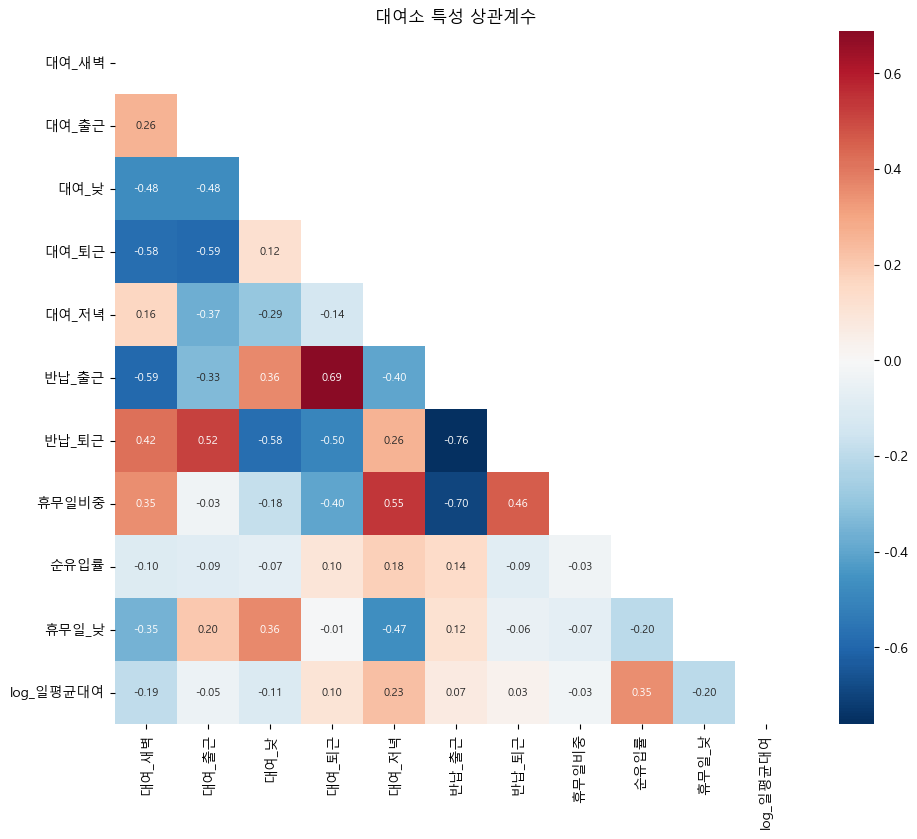

In [7]:
from sklearn.preprocessing import StandardScaler
X_st = StandardScaler().fit_transform(feat)

plt.figure(figsize=(11, 9))
corr = feat.corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, annot_kws={'size': 8})
plt.title('대여소 특성 상관계수'); save('C01_특성상관.png'); 
plt.show()

#  K-Means: 군집 수 정하기 (엘보우 + 실루엣)

- 엘보우: inertia(군집 내 거리 제곱합)가 급격히 줄다가 완만해지는 지점
- 실루엣 계수: 정답이 없을 때 쓰는 평가 지표 (2장 5절). 높을수록 군집이 잘 나뉨
- 실루엣이 가장 높은 k가 너무 작으면(2개) 운영에 쓰기 어려우므로, 실루엣이 높은 편이면서 해석 가능한 4~6개를 고르는 것도 방법입니다.

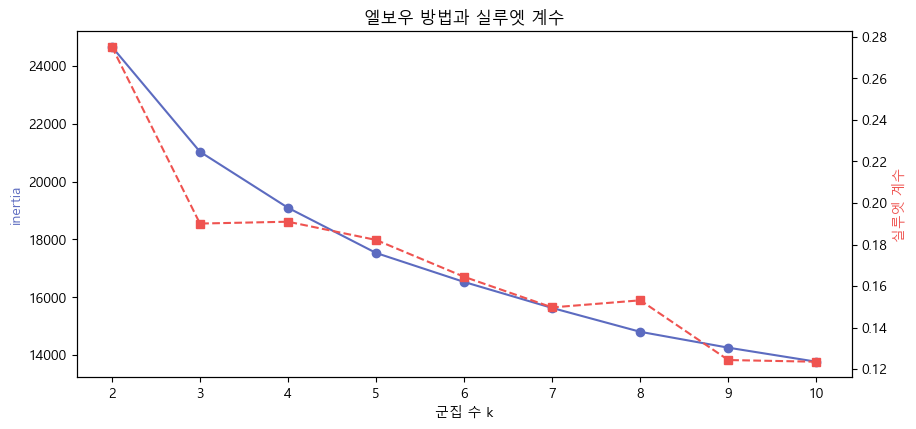

k별 실루엣: {2: 0.275, 3: 0.19, 4: 0.191, 5: 0.182, 6: 0.164, 7: 0.15, 8: 0.153, 9: 0.124, 10: 0.124}
선택한 군집 수 K = 4


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 11)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE).fit(X_st)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_st, km.labels_))

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(ks, inertia, 'o-', color='#5C6BC0'); ax1.set_xlabel('군집 수 k'); ax1.set_ylabel('inertia', color='#5C6BC0')
ax2 = ax1.twinx(); ax2.plot(ks, sil, 's--', color='#EF5350'); ax2.set_ylabel('실루엣 계수', color='#EF5350')
plt.title('엘보우 방법과 실루엣 계수'); save('C02_군집수결정.png'); plt.show()

sil_s = pd.Series(sil, index=ks)
K = int(sil_s[sil_s.index >= 4].idxmax())      # 4개 이상 중 실루엣 최고 (해석 가능한 수) → 직접 바꿔도 됨
print('k별 실루엣:', sil_s.round(3).to_dict())
print('선택한 군집 수 K =', K)

## K-Means 결과와 군집 해석

- 군집별 특성 평균을 전체 평균 대비 표준편차 단위로 색칠해서 각 군집의 특징을 읽습니다
- 가장 두드러진 특성 2개로 군집 이름을 자동으로 붙입니다. 결과를 보고 CLUSTER_NAME에 이해하기 쉬운 이름으로 바꾸세요.

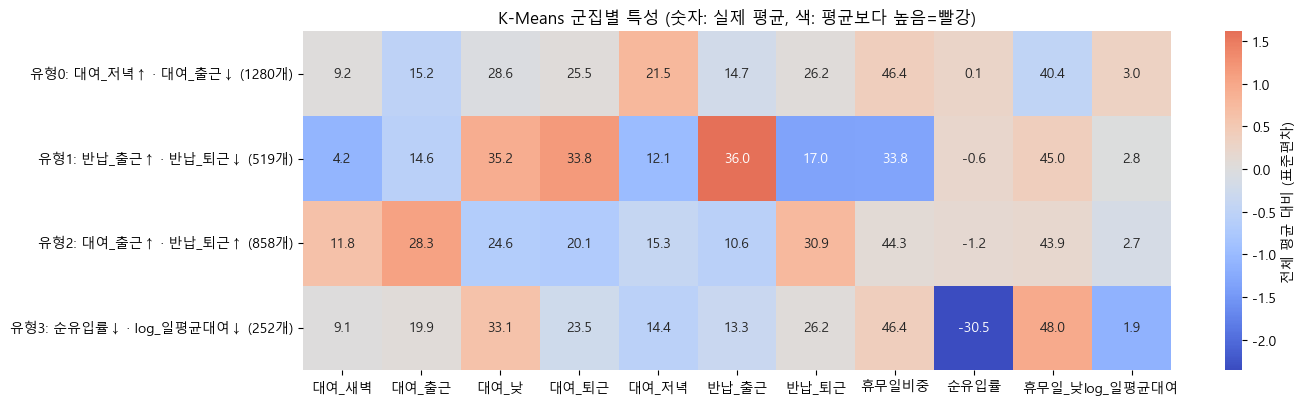

,유형,대여소 수,일평균대여(평균)
0,유형0: 대여_저녁↑ · 대여_출근↓,1280,26.2
1,유형1: 반납_출근↑ · 반납_퇴근↓,519,20.3
2,유형2: 대여_출근↑ · 반납_퇴근↑,858,18.1
3,유형3: 순유입률↓ · log_일평균대여↓,252,6.8


In [9]:
km = KMeans(n_clusters=K, init='k-means++', n_init=20, random_state=RANDOM_STATE).fit(X_st)
st['cluster'] = km.labels_

profile = feat.groupby(st['cluster']).mean()
z = (profile - feat.mean()) / feat.std()

def auto_name(row):                          # 평균에서 가장 많이 벗어난 특성 2개 (↑ 높음, ↓ 낮음)
    top = row.abs().sort_values(ascending=False).index[:2]
    return ' · '.join(f"{c}{'↑' if row[c] > 0 else '↓'}" for c in top)
CLUSTER_NAME = {c: f'유형{c}: {auto_name(z.loc[c])}' for c in z.index}
# 예) CLUSTER_NAME = {0: '주거지 출근 출발형', 1: '업무지구 도착형', 2: '한강 여가형', 3: '생활 균형형', 4: '대형 거점'}
st['유형'] = st['cluster'].map(CLUSTER_NAME)

size = st['cluster'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(14, 0.6 * K + 2))
sns.heatmap(z, annot=profile.round(1), fmt='', cmap='coolwarm', center=0, ax=ax,
            yticklabels=[f'{CLUSTER_NAME[c]} ({size[c]}개)' for c in z.index],
            cbar_kws={'label': '전체 평균 대비 (표준편차)'})
ax.set_title('K-Means 군집별 특성 (숫자: 실제 평균, 색: 평균보다 높음=빨강)'); ax.set_ylabel('')
save('C03_군집프로파일.png'); plt.show()
pd.DataFrame({'유형': CLUSTER_NAME, '대여소 수': size, '일평균대여(평균)': st.groupby('cluster')['일평균대여'].mean().round(1)})

## 유형별 시간대 패턴과 PCA 2차원 시각화

- 유형마다 평일 대여·반납이 몰리는 시간대 
- PCA로 여러 특성을 2차원으로 줄여 군집이 잘 나뉘었는지 확인

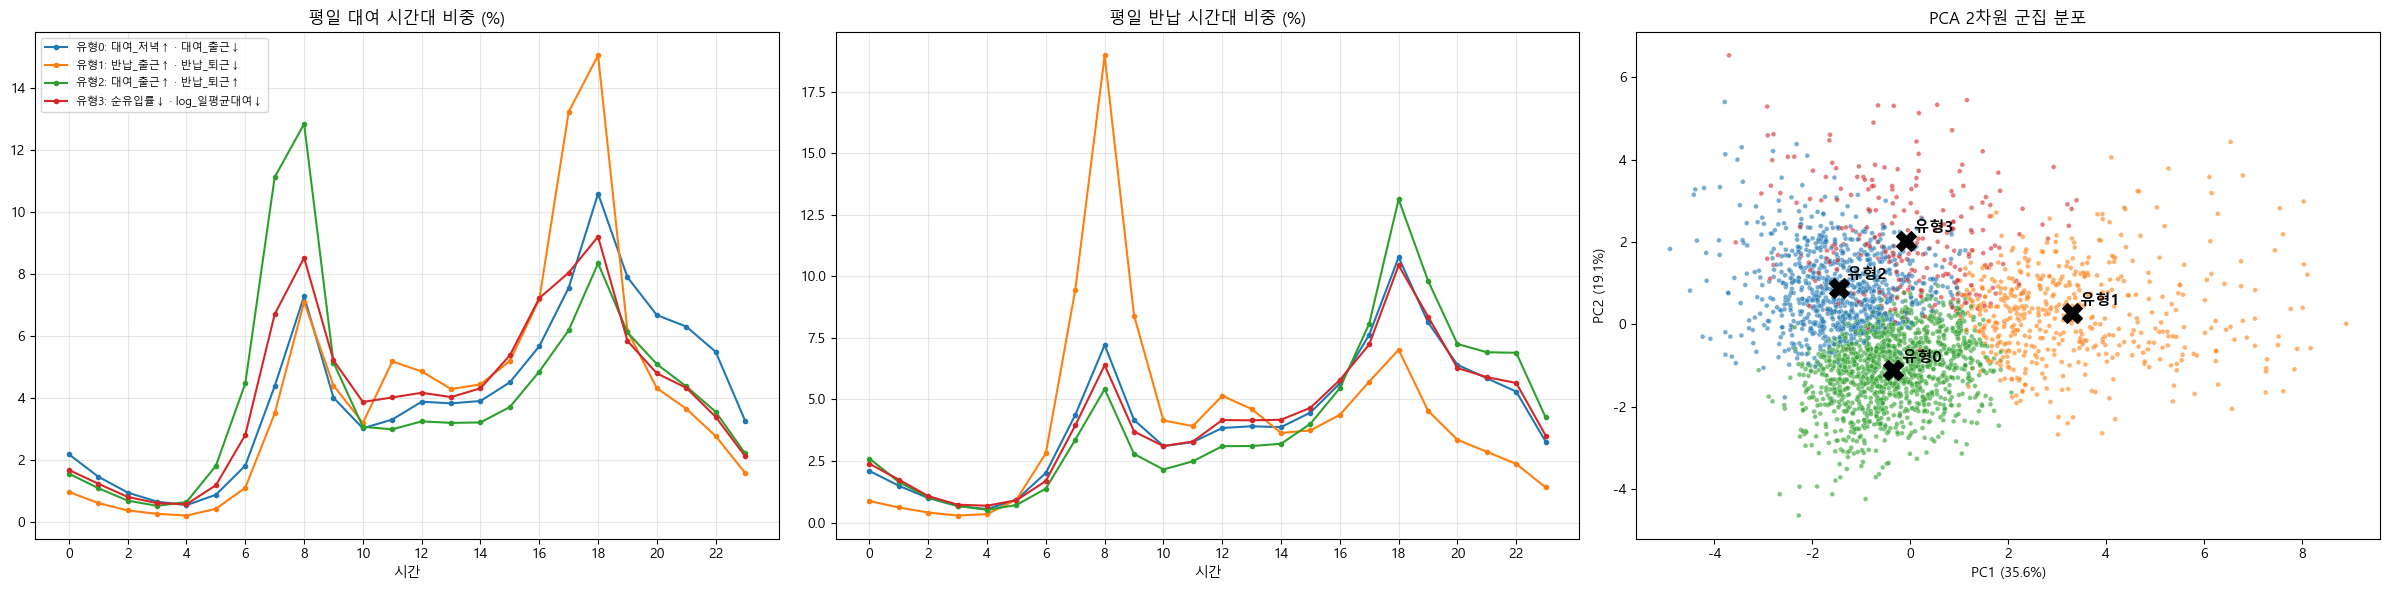

In [10]:
from sklearn.decomposition import PCA

def hourly_profile(tbl):
    t = tbl[(tbl['off'] == 0) & tbl['대여소'].isin(st.index)].copy()
    t['cluster'] = t['대여소'].map(st['cluster'])
    pv = t.pivot_table(index='cluster', columns='hour', values='cnt', aggfunc='sum')
    return pv.div(pv.sum(axis=1), axis=0) * 100

hp_rent, hp_ret = hourly_profile(st_rent), hourly_profile(st_ret)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
xy = pca.fit_transform(X_st)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for c in hp_rent.index:
    axes[0].plot(hp_rent.columns, hp_rent.loc[c], marker='o', ms=3, label=CLUSTER_NAME[c])
    axes[1].plot(hp_ret.columns, hp_ret.loc[c], marker='o', ms=3, label=CLUSTER_NAME[c])
for ax, t in zip(axes[:2], ['평일 대여 시간대 비중 (%)', '평일 반납 시간대 비중 (%)']):
    ax.set_title(t); ax.set_xticks(range(0, 24, 2)); ax.set_xlabel('시간'); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
sns.scatterplot(x=xy[:, 0], y=xy[:, 1], hue=st['유형'].values, palette='tab10', s=12, alpha=0.6, ax=axes[2], legend=False)
centers = pca.transform(km.cluster_centers_)
axes[2].scatter(centers[:, 0], centers[:, 1], c='k', marker='X', s=200)
for i, (x, y) in enumerate(centers):
    axes[2].annotate(f'유형{i}', (x, y), xytext=(6, 6), textcoords='offset points', fontsize=11, weight='bold')
ev = pca.explained_variance_ratio_
axes[2].set_xlabel(f'PC1 ({ev[0]:.1%})'); axes[2].set_ylabel(f'PC2 ({ev[1]:.1%})'); axes[2].set_title('PCA 2차원 군집 분포')
plt.tight_layout(); save('C04_유형별시간대_PCA.png'); plt.show()

# 계층적 군집과 비교

- Ward 연결법(합쳤을 때 분산 증가가 가장 작은 군집끼리 병합)은 K-Means와 비슷한 둥근 군집을 만들어 비교에 적합.
- 대여소가 많아 덴드로그램은 마지막 30개 병합만 표시 (truncate_mode='lastp').
- **2장 5절의 정답 기반 지표(ARI, AMI, V-measure)**를 "K-Means 결과를 정답으로 놓고 계층적 군집이 얼마나 같은지" 비교하는 데 사용. 두 방법이 비슷하게 나누면 군집 구조가 안정적이라는 근거.

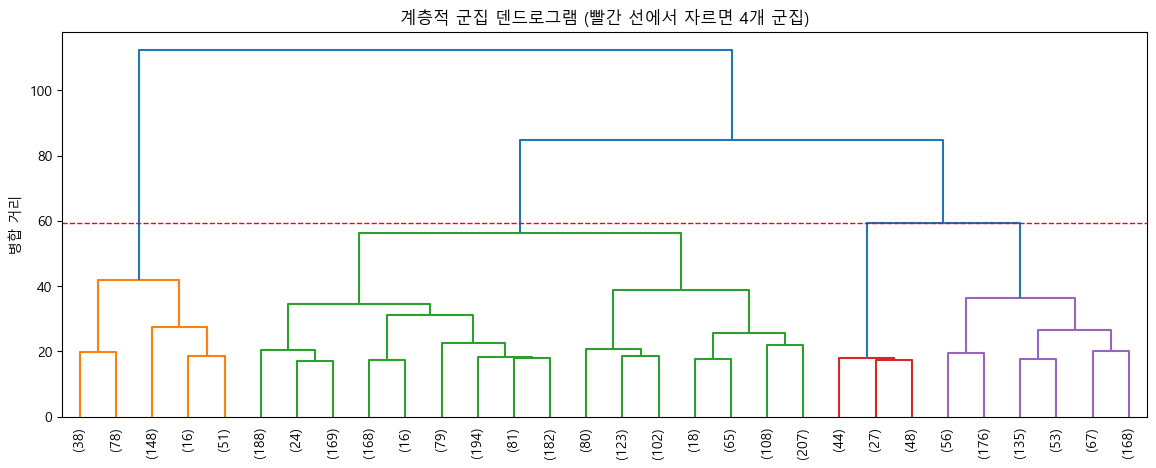

K-Means vs 계층적 군집 일치도: {'ARI': 0.47, 'AMI': 0.494, 'V-measure': 0.495}


계층적 군집 번호,0,1,2,3
K-Means 유형,,,,
유형0: 대여_저녁↑ · 대여_출근↓,0,1262,0,18
유형1: 반납_출근↑ · 반납_퇴근↓,321,190,3,5
유형2: 대여_출근↑ · 반납_퇴근↑,0,257,5,596
유형3: 순유입률↓ · log_일평균대여↓,10,95,111,36


In [11]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, v_measure_score

Z = linkage(X_st, method='ward')
plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, color_threshold=Z[-(K - 1), 2])
plt.axhline(Z[-(K - 1), 2], color='r', ls='--', lw=1)
plt.title(f'계층적 군집 덴드로그램 (빨간 선에서 자르면 {K}개 군집)'); plt.ylabel('병합 거리')
save('C05_덴드로그램.png'); plt.show()

hc = fcluster(Z, K, criterion='maxclust') - 1
st['hc'] = hc
agree = {'ARI': adjusted_rand_score(st['cluster'], hc), 'AMI': adjusted_mutual_info_score(st['cluster'], hc),
         'V-measure': v_measure_score(st['cluster'], hc)}
print('K-Means vs 계층적 군집 일치도:', {k: round(v, 3) for k, v in agree.items()})
pd.crosstab(st['유형'], st['hc'], rownames=['K-Means 유형'], colnames=['계층적 군집 번호'])

# DBSCAN: 특이 대여소 찾기

- DBSCAN은 밀도가 낮은 점을 잡음(-1)**으로 따로 분류합니다. 여기서는 다른 대여소와 패턴이 크게 다른 **특이 대여소를 찾는 데 사용합니다.

- eps 정하기: 각 점에서 min_samples번째로 가까운 이웃까지 거리를 정렬해 그린 k-거리 그래프에서 급격히 꺾이는 지점 (여기서는 95% 지점)

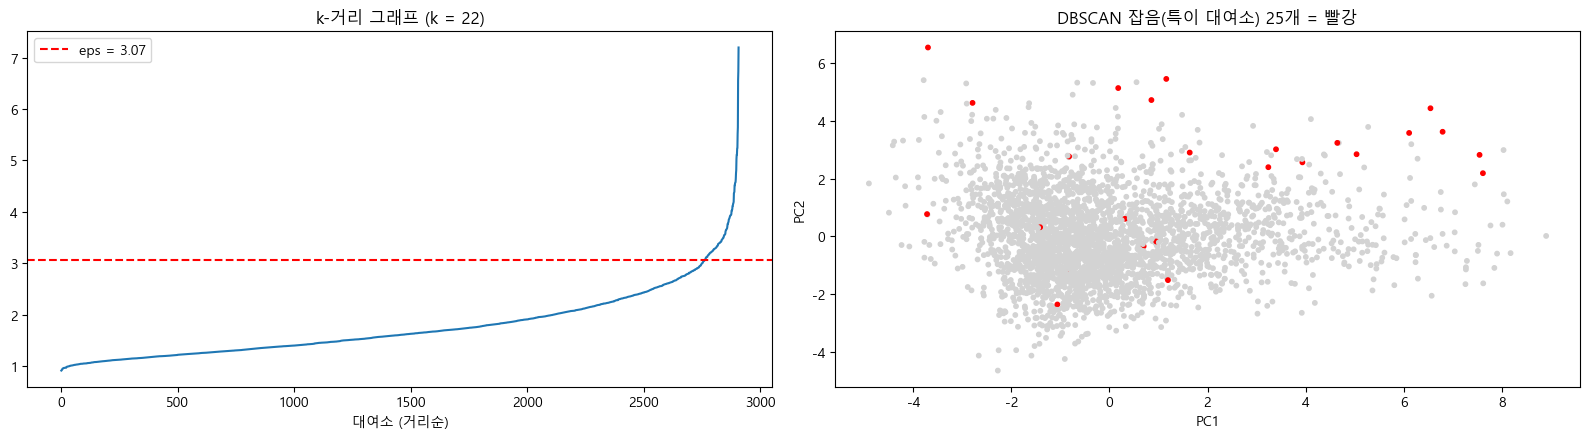

DBSCAN 군집 수(잡음 제외): 1 | 잡음: 25


,자치구,일평균대여,유형,대여_출근,반납_출근,휴무일비중,순유입률
대여소,,,,,,,
월드컵공원,마포구,54.5,유형0: 대여_저녁↑ · 대여_출근↓,5.9,15.0,76.4,-0.3
서울숲 관리사무소,성동구,45.4,유형0: 대여_저녁↑ · 대여_출근↓,4.0,7.3,71.9,-2.1
서울복합물류 게이트 1,송파구,25.2,유형0: 대여_저녁↑ · 대여_출근↓,16.3,32.7,39.5,2.1
철도교통관제센터 정문 앞,구로구,21.6,유형1: 반납_출근↑ · 반납_퇴근↓,36.3,49.9,42.4,2.2
올림픽공원 수영장,송파구,17.7,유형0: 대여_저녁↑ · 대여_출근↓,21.4,19.2,40.2,2.5
양천해누리체육공원,양천구,17.5,유형1: 반납_출근↑ · 반납_퇴근↓,10.5,70.3,23.6,13.6
삼일초등학교 인근,동작구,9.1,유형2: 대여_출근↑ · 반납_퇴근↑,14.9,4.8,42.9,-7.4
국회도서관,영등포구,8.7,유형1: 반납_출근↑ · 반납_퇴근↓,4.8,30.5,25.4,-5.0
양원보도육교,양천구,8.1,유형1: 반납_출근↑ · 반납_퇴근↓,11.0,72.5,14.2,-1.9


In [12]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 2 * X_st.shape[1]                 # 흔히 쓰는 기준: 특성 수의 2배
dist, _ = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_st).kneighbors(X_st)
kdist = np.sort(dist[:, -1])
EPS = float(np.percentile(kdist, 95))

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(X_st)
st['dbscan'] = db.labels_
n_noise = (db.labels_ == -1).sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
axes[0].plot(kdist); axes[0].axhline(EPS, color='r', ls='--', label=f'eps = {EPS:.2f}')
axes[0].set_title(f'k-거리 그래프 (k = {MIN_SAMPLES})'); axes[0].set_xlabel('대여소 (거리순)'); axes[0].legend()
axes[1].scatter(xy[:, 0], xy[:, 1], c=np.where(db.labels_ == -1, 'red', 'lightgray'), s=10)
axes[1].set_title(f'DBSCAN 잡음(특이 대여소) {n_noise}개 = 빨강'); axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.tight_layout(); save('C06_DBSCAN특이대여소.png'); plt.show()

print('DBSCAN 군집 수(잡음 제외):', len(set(db.labels_)) - (1 if -1 in db.labels_ else 0), '| 잡음:', n_noise)
odd = st[st['dbscan'] == -1].join(feat[['대여_출근', '반납_출근', '휴무일비중', '순유입률']])
odd.sort_values('일평균대여', ascending=False)[['자치구', '일평균대여', '유형', '대여_출근', '반납_출근', '휴무일비중', '순유입률']].head(15).round(1)

# 군집 모형 평가 비교와 결과 저장

- 정답이 없는 군집은 실루엣 계수(높을수록 좋음), Calinski-Harabasz(높을수록 좋음), Davies-Bouldin(낮을수록 좋음)으로 비교.

- DBSCAN은 잡음을 뺀 대여소로만 계산.

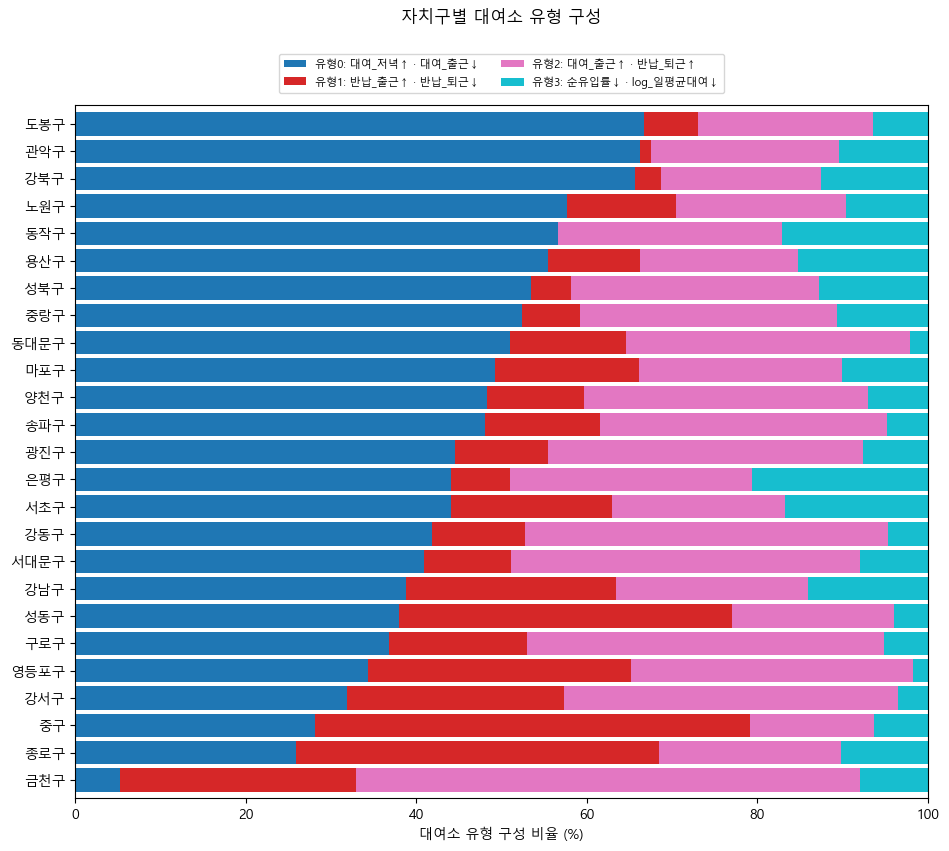

,군집 수,실루엣↑,Calinski-Harabasz↑,Davies-Bouldin↓
모델,,,,
K-Means,4,0.191,654.680,1.563
계층적(Ward),4,0.181,556.242,1.512


In [13]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

rows = []
for name, lab, mask in [('K-Means', st['cluster'].values, np.ones(len(st), bool)),
                        ('계층적(Ward)', hc, np.ones(len(st), bool)),
                        ('DBSCAN', db.labels_, db.labels_ != -1)]:
    if len(set(lab[mask])) > 1:
        rows.append({'모델': name, '군집 수': len(set(lab[mask])),
                     '실루엣↑': silhouette_score(X_st[mask], lab[mask]),
                     'Calinski-Harabasz↑': calinski_harabasz_score(X_st[mask], lab[mask]),
                     'Davies-Bouldin↓': davies_bouldin_score(X_st[mask], lab[mask])})
cluster_eval = pd.DataFrame(rows).set_index('모델').round(3)

comp = pd.crosstab(st['자치구'], st['유형'], normalize='index') * 100
ax = comp.loc[comp.iloc[:, 0].sort_values().index].plot(kind='barh', stacked=True, figsize=(11, 9),
                                                        colormap='tab10', width=0.85)
ax.set_xlim(0, 100); ax.set_xlabel('대여소 유형 구성 비율 (%)'); ax.set_ylabel('')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, fontsize=8)
ax.set_title('자치구별 대여소 유형 구성', pad=60)
save('C07_자치구별유형구성.png'); plt.show()

st.join(feat).to_csv(os.path.join(OUT_DIR, '대여소유형_결과.csv'), encoding='utf-8-sig')
cluster_eval

# Part 2. 분류분석 (3장) - 7일 뒤 자치구 재배치 상태 예측


# 목표값(클래스) 정의

- 자치구 × 날짜마다 순유입률 = (반납 − 대여) / 대여를 계산하고 3개 클래스로 나눈다.

- 기준(5%)은 THRESHOLD로 바꿀 수 있습니다. 운영 여력(트럭 수)에 맞춰 정합니다

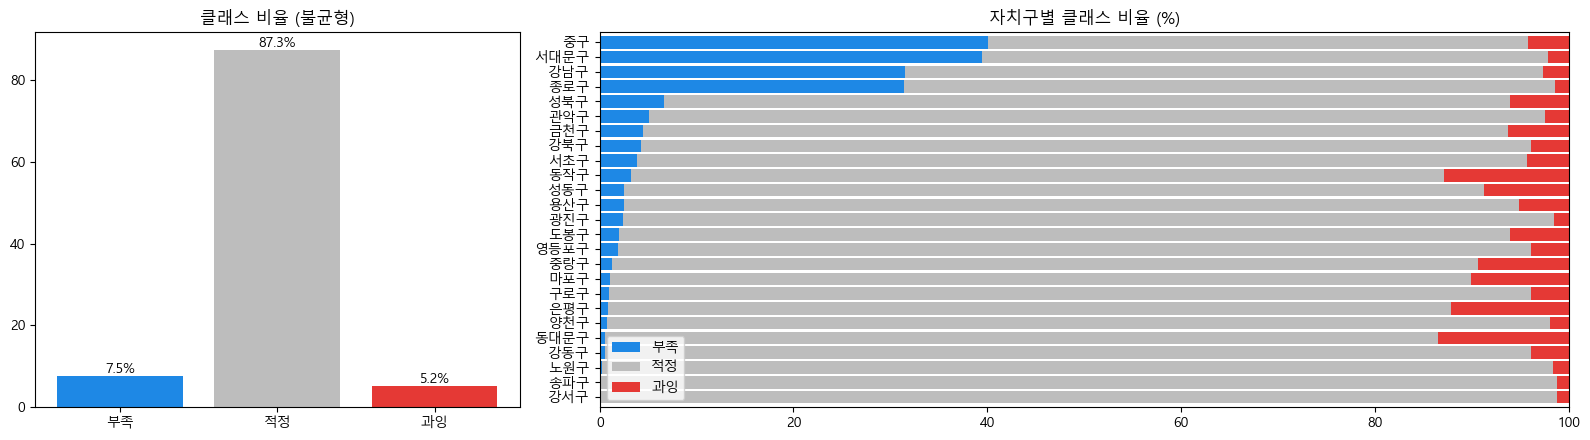

In [14]:
THRESHOLD = 0.05
CLASS_NAMES = ['부족', '적정', '과잉']

gu_panel = (pd.MultiIndex.from_product([sorted(gu_rent['자치구'].unique()), all_days], names=['자치구', 'date'])
            .to_frame(index=False)
            .merge(gu_rent, on=['자치구', 'date'], how='left').merge(gu_ret, on=['자치구', 'date'], how='left')
            .fillna({'rent': 0, 'ret': 0}))
gu_panel['net'] = gu_panel['ret'] - gu_panel['rent']
gu_panel['ratio'] = gu_panel['net'] / gu_panel['rent'].clip(lower=1)
gu_panel['y'] = np.select([gu_panel['ratio'] <= -THRESHOLD, gu_panel['ratio'] >= THRESHOLD], [0, 2], 1)

dist = gu_panel['y'].value_counts(normalize=True).sort_index() * 100
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), gridspec_kw={'width_ratios': [1, 2]})
bars = axes[0].bar(CLASS_NAMES, dist.values, color=['#1E88E5', '#BDBDBD', '#E53935'])
axes[0].bar_label(bars, fmt='%.1f%%'); axes[0].set_title('클래스 비율 (불균형)')
gu_cls = pd.crosstab(gu_panel['자치구'], gu_panel['y'], normalize='index') * 100
gu_cls.columns = CLASS_NAMES
gu_cls.sort_values('부족').plot(kind='barh', stacked=True, ax=axes[1], color=['#1E88E5', '#BDBDBD', '#E53935'], width=0.85)
axes[1].set_xlim(0, 100); axes[1].set_title('자치구별 클래스 비율 (%)'); axes[1].set_ylabel('')
plt.tight_layout(); save('K01_클래스분포.png'); plt.show()

# 특성 만들기 (7일 전에 알 수 있는 정보만)

- 예측 시점에 알 수 없는 정보(그날의 실제 대여량 등)를 쓰면 데이터 누수가 됩니다. 시차 특성은 모두 HORIZON(7)일 이전 값입니다.
- 군집 결과 연결: 자치구별 대여소 유형 구성 비율(Part 1)을 특성으로 넣습니다. "업무지구 도착형이 많은 구는 평일에 자전거가 쌓인다" 같은 구조적 차이를 모델이 배울 수 있습니다

In [15]:
def make_class_features(panel, horizon=HORIZON, future_days=HORIZON):
    df = panel[['자치구', 'date', 'rent', 'ratio', 'y']].copy()
    last = df['date'].max()
    fut = pd.MultiIndex.from_product([df['자치구'].unique(), pd.date_range(last + pd.Timedelta(days=1), periods=future_days)],
                                     names=['자치구', 'date']).to_frame(index=False)
    df = pd.concat([df, fut], ignore_index=True).sort_values(['자치구', 'date']).reset_index(drop=True)
    d = df['date']
    df['dow'] = d.dt.dayofweek
    df['offday'] = ((df['dow'] >= 5) | d.isin(HOLIDAYS)).astype(int)
    df['next_off'] = (((d + pd.Timedelta(days=1)).dt.dayofweek >= 5) | (d + pd.Timedelta(days=1)).isin(HOLIDAYS)).astype(int)
    df['month'] = d.dt.month
    df['doy_sin'], df['doy_cos'] = np.sin(2 * np.pi * d.dt.dayofyear / 365.25), np.cos(2 * np.pi * d.dt.dayofyear / 365.25)

    g = df.groupby('자치구')
    for lag in [7, 14, 21, 28]:
        if lag >= horizon:
            df[f'ratio_lag{lag}'] = g['ratio'].shift(lag)
    sh = g['ratio'].shift(horizon)
    df['ratio_roll7'] = sh.groupby(df['자치구']).transform(lambda s: s.rolling(7, min_periods=5).mean())
    df['ratio_roll28'] = sh.groupby(df['자치구']).transform(lambda s: s.rolling(28, min_periods=20).mean())
    df['ratio_dow4'] = df[[f'ratio_lag{l}' for l in [7, 14, 21, 28] if l >= horizon]].mean(axis=1)
    df['log_rent_lag'] = np.log1p(g['rent'].shift(horizon))
    df['y_lag'] = g['y'].shift(horizon)
    ysh = g['y'].shift(horizon)
    df['short_rate28'] = (ysh == 0).astype(float).where(ysh.notna()).groupby(df['자치구']).transform(lambda s: s.rolling(28, min_periods=20).mean())
    df['over_rate28'] = (ysh == 2).astype(float).where(ysh.notna()).groupby(df['자치구']).transform(lambda s: s.rolling(28, min_periods=20).mean())

    comp_feat = pd.crosstab(st['자치구'], st['cluster'], normalize='index').add_prefix('유형비율_')
    df = df.merge(comp_feat, left_on='자치구', right_index=True, how='left')
    return df


In [16]:
data = make_class_features(gu_panel)
FEATURES = [c for c in data.columns if c not in ['자치구', 'date', 'rent', 'ratio', 'y']]
known = data.dropna(subset=['y'] + FEATURES)
future = data[data['date'] > gu_panel['date'].max()]

# 시간 순서 분리: 여러 해면 마지막 1년, 1년치면 마지막 25% 기간을 시험 데이터로
dates = np.sort(known['date'].unique())
span = (dates[-1] - dates[0]) / np.timedelta64(1, 'D')
TEST_START = (pd.Timestamp(dates[-1]) - pd.Timedelta(days=364)) if span > 600 else pd.Timestamp(dates[int(len(dates) * 0.75)])
train, test = known[known['date'] < TEST_START].sort_values('date'), known[known['date'] >= TEST_START]
X_train, y_train, X_test, y_test = train[FEATURES], train['y'].astype(int), test[FEATURES], test['y'].astype(int)

print('특성', len(FEATURES), '개:', FEATURES)
print(f'학습 {len(train):,}행 ({train["date"].min().date()} ~ {train["date"].max().date()}) | '
      f'시험 {len(test):,}행 ({test["date"].min().date()} ~ {test["date"].max().date()}) | 미래 {len(future)}행')

특성 21 개: ['dow', 'offday', 'next_off', 'month', 'doy_sin', 'doy_cos', 'ratio_lag7', 'ratio_lag14', 'ratio_lag21', 'ratio_lag28', 'ratio_roll7', 'ratio_roll28', 'ratio_dow4', 'log_rent_lag', 'y_lag', 'short_rate28', 'over_rate28', '유형비율_0', '유형비율_1', '유형비율_2', '유형비율_3']
학습 44,975행 (2020-01-29 ~ 2024-12-31) | 시험 9,125행 (2025-01-01 ~ 2025-12-31) | 미래 175행


# 3장 분류 모형 6종 비교

*    - 정확도만 보면 "모두 적정"이라고만 답해도 78%가 나오므로 부족
*    - macro F1: 세 클래스의 F1을 단순 평균 → 소수 클래스(부족·과잉)도 똑같이 중요하게 평가 (모델 선택 기준)
*    - 부족 재현율: 실제 부족한 날 중 몇 %를 찾았는지 (놓치면 시민이 자전거를 못 빌림)
*    - ROC AUC (OvR): 클래스별 "이 클래스 vs 나머지" ROC 면적의 평균
- 거리·경사하강법 기반 모델은 StandardScaler와 함께 Pipeline으로 묶습니다
- 기준 모델 2개: "항상 적정", "7일 전 상태가 그대로"



In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score, roc_auc_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)


In [18]:
def evaluate(name, y_true, y_pred, proba=None):
    return {'모델': name,
            '정확도': accuracy_score(y_true, y_pred),
            'macro F1': f1_score(y_true, y_pred, average='macro'),
            '부족 재현율': recall_score(y_true, y_pred, labels=[0], average='macro'),
            '부족 정밀도': precision_score(y_true, y_pred, labels=[0], average='macro', zero_division=0),
            '과잉 재현율': recall_score(y_true, y_pred, labels=[2], average='macro'),
            'ROC AUC': roc_auc_score(y_true, proba, multi_class='ovr') if proba is not None else np.nan}

results = [evaluate('기준: 항상 적정', y_test, np.ones(len(y_test), int)),
           evaluate('기준: 7일 전 상태', y_test, test['y_lag'].astype(int))]

def scaled(model):
    return Pipeline([('scaler', StandardScaler()), ('model', model)])

base_models = {
    '로지스틱 회귀': scaled(LogisticRegression(max_iter=2000)),
    '나이브 베이즈': scaled(GaussianNB()),
    'QDA': scaled(QuadraticDiscriminantAnalysis(reg_param=0.1)),
    '의사결정나무': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'SVM': scaled(SVC(probability=True, random_state=RANDOM_STATE)),
    'MLP(인공신경망)': scaled(MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=800, early_stopping=True,
                                          random_state=RANDOM_STATE)),
}
fitted = {}
for name, model in base_models.items():
    t = time.time()
    model.fit(X_train, y_train)
    fitted[name] = model
    results.append(evaluate(name, y_test, model.predict(X_test), model.predict_proba(X_test)))
    print(f'{name}: {time.time() - t:.1f}초')

base_df = pd.DataFrame(results).set_index('모델').round(3)
base_df

로지스틱 회귀: 0.6초
나이브 베이즈: 0.1초
QDA: 0.1초
의사결정나무: 0.4초
SVM: 544.8초
MLP(인공신경망): 9.0초


,정확도,macro F1,부족 재현율,부족 정밀도,과잉 재현율,ROC AUC
모델,,,,,,
기준: 항상 적정,0.904,0.317,0.000,0.000,0.000,NaN
기준: 7일 전 상태,0.859,0.460,0.305,0.306,0.150,NaN
로지스틱 회귀,0.906,0.406,0.175,0.558,0.000,0.795
나이브 베이즈,0.857,0.517,0.637,0.345,0.166,0.785
QDA,0.874,0.510,0.518,0.369,0.134,0.781
의사결정나무,0.901,0.430,0.279,0.446,0.000,0.774
SVM,0.906,0.422,0.229,0.509,0.000,0.653
MLP(인공신경망),0.903,0.456,0.376,0.465,0.003,0.803


# 모형 최적화

## 변수 선택과 차원 축소

- 랜덤포레스트 변수 중요도와 누적 합, SelectKBest(ANOVA F) 점수, RFE로 고른 변수를 비교

- 변수 수를 바꿔 가며 시계열 교차검증 macro F1이 어떻게 변하는지 보고 사용할 변수 수를 정합니

- 시계열이므로 교차검증은 TimeSeriesSplit(앞부분으로 학습 → 바로 다음 기간으로 평가)을 씁니다.

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

In [20]:
tscv = TimeSeriesSplit(n_splits=4)
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
kb = SelectKBest(f_classif, k='all').fit(X_train, y_train)
fscore = pd.Series(kb.scores_, index=FEATURES).reindex(imp.index)
rfe = RFE(RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=RANDOM_STATE),
          n_features_to_select=10).fit(X_train, y_train)
rfe_sel = [f for f, s in zip(FEATURES, rfe.support_) if s]

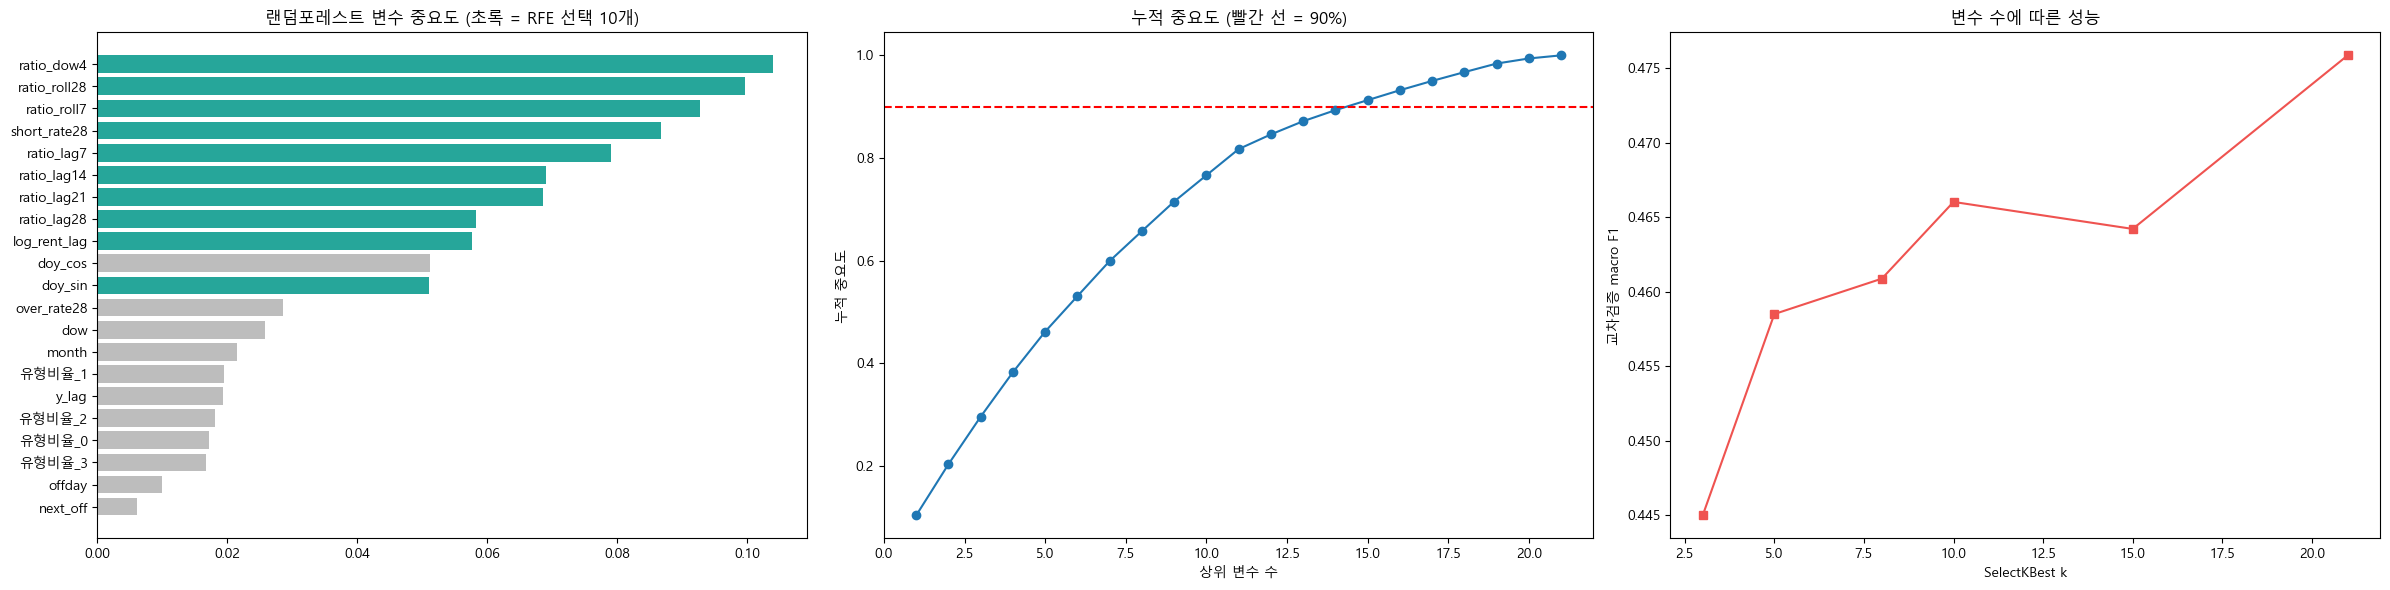

RFE 선택 변수: ['doy_sin', 'ratio_lag7', 'ratio_lag14', 'ratio_lag21', 'ratio_lag28', 'ratio_roll7', 'ratio_roll28', 'ratio_dow4', 'log_rent_lag', 'short_rate28']
교차검증 기준 최적 변수 수: 21


,RF 중요도,ANOVA F,RFE 선택
ratio_dow4,0.104,2999.418,True
ratio_roll28,0.100,5883.733,True
ratio_roll7,0.093,3655.194,True
short_rate28,0.087,10208.837,True
ratio_lag7,0.079,1102.267,True
ratio_lag14,0.069,1064.340,True
ratio_lag21,0.068,1108.431,True
ratio_lag28,0.058,856.263,True
log_rent_lag,0.058,494.445,True
doy_cos,0.051,38.060,False


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
axes[0].barh(imp.index[::-1], imp.values[::-1], color=['#26A69A' if f in rfe_sel else '#BDBDBD' for f in imp.index[::-1]])
axes[0].set_title('랜덤포레스트 변수 중요도 (초록 = RFE 선택 10개)')
axes[1].plot(range(1, len(imp) + 1), imp.cumsum().values, 'o-'); axes[1].axhline(0.9, color='r', ls='--')
axes[1].set_xlabel('상위 변수 수'); axes[1].set_ylabel('누적 중요도'); axes[1].set_title('누적 중요도 (빨간 선 = 90%)')

ks = [3, 5, 8, 10, 15, len(FEATURES)]
cv_f1 = [cross_val_score(Pipeline([('select', SelectKBest(f_classif, k=k)),
                                   ('rf', RandomForestClassifier(n_estimators=200, min_samples_leaf=3, n_jobs=-1,
                                                                 random_state=RANDOM_STATE))]),
                         X_train, y_train, cv=tscv, scoring='f1_macro').mean() for k in ks]
axes[2].plot(ks, cv_f1, 's-', color='#EF5350'); axes[2].set_xlabel('SelectKBest k'); axes[2].set_ylabel('교차검증 macro F1')
axes[2].set_title('변수 수에 따른 성능')
plt.tight_layout(); save('K02_변수선택.png'); plt.show()

BEST_K = ks[int(np.argmax(cv_f1))]
print('RFE 선택 변수:', rfe_sel)
print('교차검증 기준 최적 변수 수:', BEST_K)
pd.DataFrame({'RF 중요도': imp, 'ANOVA F': fscore, 'RFE 선택': [f in rfe_sel for f in imp.index]}).round(3)

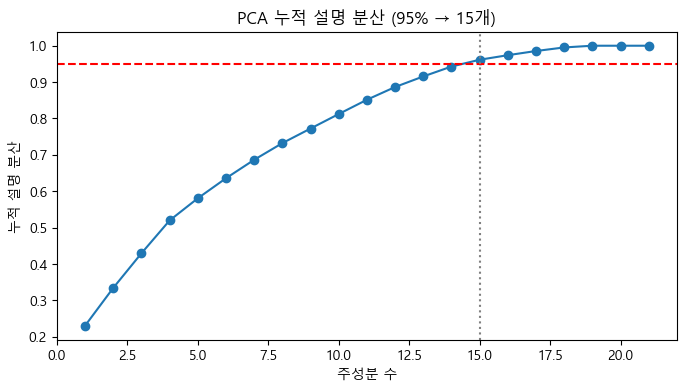

특성 21개 → 주성분 15개


In [22]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(StandardScaler().fit_transform(X_train))
cum = np.cumsum(pca_full.explained_variance_ratio_)
n95 = int(np.argmax(cum >= 0.95) + 1)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum) + 1), cum, 'o-'); plt.axhline(0.95, color='r', ls='--')
plt.axvline(n95, color='gray', ls=':'); plt.xlabel('주성분 수'); plt.ylabel('누적 설명 분산')
plt.title(f'PCA 누적 설명 분산 (95% → {n95}개)'); save('K03_PCA.png'); plt.show()

pca_lr = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)),
                   ('model', LogisticRegression(max_iter=2000))]).fit(X_train, y_train)
results.append(evaluate(f'로지스틱 회귀 + PCA({n95}개)', y_test, pca_lr.predict(X_test), pca_lr.predict_proba(X_test)))
print(f'특성 {len(FEATURES)}개 → 주성분 {n95}개')

# 파라미터 탐색

- Pipeline(전처리 + 변수 선택 + 모델) 전체를 GridSearchCV로 탐색합니다. 파이프라인 안의 파라미터 이름은 단계이름__파라미터.

- 평가 기준 scoring='f1_macro', 교차검증 TimeSeriesSplit → 시험 데이터는 탐색에 쓰지 않습니다.

- validation_curve로 트리 깊이에 따른 과적합(학습 점수 ↑, 검증 점수 ↓)을 확인

- 후보 조합 수 × 교차검증 4번만큼 학습하므로 시간이 걸립니다 (2020년 1년치, CPU 1개 기준 약 10분). 오래 걸리면 후보 값을 줄이세요.

In [ ]:
from sklearn.model_selection import GridSearchCV, validation_curve

rf_pipe = Pipeline([('select', SelectKBest(f_classif)),
                    ('model', RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE))])
rf_grid = GridSearchCV(rf_pipe, {'select__k': sorted({BEST_K, 10, len(FEATURES)}),
                                 'model__n_estimators': [300],
                                 'model__max_depth': [6, 10, None],
                                 'model__min_samples_leaf': [1, 5, 10],
                                 'model__class_weight': [None, 'balanced']},
                       cv=tscv, scoring='f1_macro', n_jobs=1).fit(X_train, y_train)

svc_pipe = Pipeline([('scaler', StandardScaler()), ('select', SelectKBest(f_classif)),
                     ('model', SVC(probability=True, random_state=RANDOM_STATE))])
svc_grid = GridSearchCV(svc_pipe, {'select__k': sorted({BEST_K, len(FEATURES)}),
                                   'model__C': [0.3, 1, 3, 10], 'model__gamma': ['scale', 0.01, 0.1],
                                   'model__class_weight': [None, 'balanced']},
                        cv=tscv, scoring='f1_macro', n_jobs=1).fit(X_train, y_train)

for name, g in [('랜덤포레스트', rf_grid), ('SVM', svc_grid)]:
    print(f'{name} 최적 파라미터: {g.best_params_} | 교차검증 macro F1 = {g.best_score_:.3f}')
    results.append(evaluate(f'{name}(GridSearch)', y_test, g.predict(X_test), g.predict_proba(X_test)))

depths = [2, 4, 6, 8, 10, 14, 20]
tr_sc, va_sc = validation_curve(RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=RANDOM_STATE),
                                X_train, y_train, param_name='max_depth', param_range=depths,
                                cv=tscv, scoring='f1_macro')
plt.figure(figsize=(8, 4))
plt.plot(depths, tr_sc.mean(axis=1), 'o-', label='학습'); plt.plot(depths, va_sc.mean(axis=1), 's-', label='교차검증')
plt.xlabel('max_depth'); plt.ylabel('macro F1'); plt.legend(); plt.title('랜덤포레스트 깊이에 따른 과적합 확인')
save('K04_검증곡선.png'); plt.show()